# Machine Learning Pipeline for Queen Bee Acoustic Monitoring

# Import Library & Setup Environment

In [19]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import random
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from dotenv import load_dotenv
from huggingface_hub import login
from transformers import ASTFeatureExtractor, ASTForAudioClassification
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score

In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


In [ ]:
RAW_AUDIO_DIR = 'dataset'
LABEL_CSV = 'dataset/state_labels.csv'

In [ ]:
WINDOW_SEC = 5.0

df_labels = pd.read_csv(LABEL_CSV)
new_records = []

print("Finding all audio files in folder")
audio_files_map = {}
for root, dirs, files in os.walk(RAW_AUDIO_DIR):
    for file in files:
        if file.endswith('.wav') or file.endswith('.mp3'):
            base_name = os.path.splitext(file)[0]
            audio_files_map[base_name] = os.path.join(root, file)

print(f"Find all {len(audio_files_map)} File (Ready for matching with CSV)")

print("Start slicing audio file")
for _, row in tqdm(df_labels.iterrows(), total=len(df_labels)):
    sample_name = str(row['sample_name']).strip()
    label = str(row['label']).strip().lower()

    if label not in ['active', 'missing queen']: continue
    
    if sample_name not in audio_files_map:
        continue 
        
    file_path = audio_files_map[sample_name]
        
    try:
        info = torchaudio.info(file_path)
        sr = info.sample_rate
        total_frames = info.num_frames
        chunk_frames = int(sr * WINDOW_SEC)
        
        for start_frame in range(0, total_frames, chunk_frames):
            end_frame = start_frame + chunk_frames
            if end_frame > total_frames: break # ทิ้งเศษท้ายคลิป
            
            numeric_label = 0 if label == 'active' else 1
            new_records.append({
                'audio_path': file_path,
                'hive_id': sample_name.split('_')[0], 
                'start_frame': start_frame,
                'num_frames': chunk_frames,
                'label': numeric_label
            })

    except Exception as e:
        pass

df_processed = pd.DataFrame(new_records)
df_processed.to_csv('virtual_hive_state_dataset.csv', index=False)
print(f"Finish slicing audio files, received {len(df_processed)} Files")

Finding all audio files in folder
Find all 576 File (Ready for matching with CSV)
Start slicing audio file


  0%|          | 0/573 [00:00<?, ?it/s]

Finish slicing audio files, received 67049 Files


In [ ]:
TARGET_SR = 22050
feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

class VirtualHiveStateDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        start_frame = int(row['start_frame'])
        num_frames = int(row['num_frames'])

        try:
            waveform, sr = torchaudio.load(row['audio_path'], frame_offset=start_frame, num_frames=num_frames)
            
            # Resample ถ้าเสียงไม่ได้มาในระดับ 22050 Hz
            if sr != TARGET_SR:
                waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=TARGET_SR)(waveform)
            
            # บังคับ Mono
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            if self.augment:
                waveform = waveform * random.uniform(0.7, 1.2)
                if random.random() < 0.4:
                    noise = torch.randn_like(waveform) * random.uniform(0.001, 0.01)
                    waveform += noise

            waveform_np = waveform.numpy()[0]

        except Exception:
            waveform_np = np.zeros(int(TARGET_SR * 5.0))

        inputs = feature_extractor(waveform_np, sampling_rate=TARGET_SR, return_tensors="pt")
        ast_tensor = inputs.input_values[0]
        label = torch.tensor(row['label'], dtype=torch.long)
        return ast_tensor, label

df_all = pd.read_csv('virtual_hive_state_dataset.csv')

sgkf = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in sgkf.split(df_all, df_all['label'], groups=df_all['hive_id']):
    df_train = df_all.iloc[train_idx]
    df_test = df_all.iloc[test_idx]
    break

# Build data loader
BATCH_SIZE = 32

train_loader = DataLoader(
    VirtualHiveStateDataset(df_train, augment=True), 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    VirtualHiveStateDataset(df_test, augment=False), 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)
print(f"Data is ready Train: {len(df_train)} | Test: {len(df_test)}")

Data is ready Train: 49961 | Test: 17088


In [ ]:
class ModernHiveASTModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
        #     sample_rate=22050, 
        #     n_mels=64, 
        #     n_fft=1024,
        #     hop_length=512,
        #     f_min=50.0,   
        #     f_max=8000.0
        # )
        # self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

        # self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=8)
        # self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=20)

        # self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # for param in self.resnet.parameters():
        #     param.requires_grad = False
        # for param in self.resnet.layer4.parameters():
        #     param.requires_grad = True
            
        # self.resnet.fc = nn.Sequential(
        #     nn.Dropout(0.6),
        #     nn.Linear(self.resnet.fc.in_features, num_classes)
        # )

        self.ast = ASTForAudioClassification.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593",
            ignore_mismatched_sizes=True,
            num_labels=num_classes
        )

    def forward(self, x):
        # x: (Batch, 1, Time)
        # x = self.mel_spectrogram(x)
        outputs = self.ast(x)
        return outputs.logits

model = ModernHiveASTModel(num_classes=2).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print("Builted AI Model leaw :)")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([2])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Builted AI Model leaw :)


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
EPOCHS = 20
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}

print("Starting Training Modelll")
for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        current_train_acc = (train_correct / train_total) * 100
        train_loop.set_postfix(loss=loss.item(), acc=f"{current_train_acc:.2f}%")
        
    train_loss = train_loss / len(train_loader.dataset)
    train_acc = (train_correct / train_total) * 100
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    all_val_preds = []
    all_val_labels = []
    
    val_loop = tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Test]")
    with torch.no_grad():
        for inputs, labels in val_loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Calculate Loss และ Accuracy ของ Validation
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

            current_val_acc = (val_correct / val_total) * 100
            val_loop.set_postfix(loss=loss.item(), acc=f"{current_val_acc:.2f}%")
            
    val_loss = val_loss / len(test_loader.dataset)
    val_acc = (val_correct / val_total) * 100
    
    # Calculate Recall และ F1-Score
    val_recall = recall_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

    # Update Learning Rate Scheduler
    scheduler.step(val_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1}:")
    print(f"   Train => Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"   Val   => Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | Recall: {val_recall:.4f} | F1: {val_f1:.4f}\n")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_hive_state_model.pth') 
        print(f"Saved NEW Best Model! (Val acc: {best_val_acc:.2f}%)\n")

Starting Training Modelll


Epoch 1/20 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Last Evaluate

 Classification Report:
                   precision    recall  f1-score   support

       Active (0)       0.79      0.85      0.82     16595
Missing Queen (1)       0.84      0.77      0.80     16676

         accuracy                           0.81     33271
        macro avg       0.81      0.81      0.81     33271
     weighted avg       0.81      0.81      0.81     33271



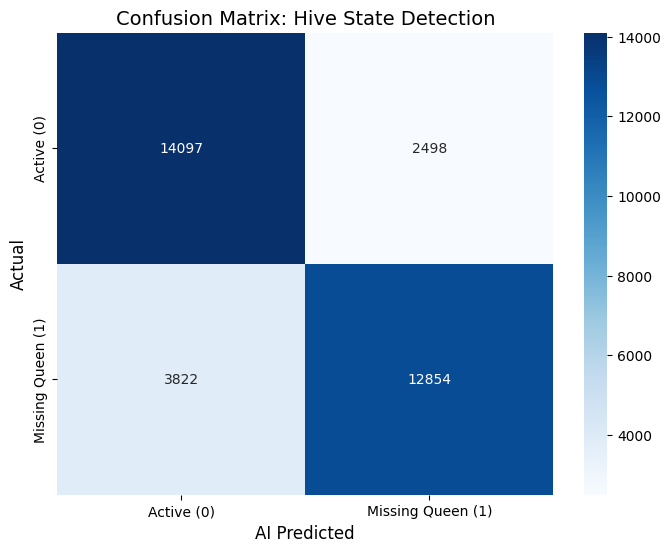

In [ ]:
model.load_state_dict(torch.load('best_hive_state_model.pth'))
model.eval()

all_preds = []
all_labels = []

print("Last Evaluate")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ['Active (0)', 'Missing Queen (1)']
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Hive State Detection', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('AI Predicted', fontsize=12)
plt.show()